# Comparison of Placement Algorithms

This notebook compares the performance metrics (latency and network usage) between two YAFS placement algorithms:
1. **Latency-based (Baseline)**
2. **Custom Proposed Strategy**

The analysis uses simulation trace data generated by YAFS.

In [135]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

In [136]:
# Define file paths
results_dir = 'resultados'

# Latency Strategy Files
latency_trace_file = os.path.join(results_dir, '4-latency-sim_trace.csv')
latency_link_file = os.path.join(results_dir, '4-latency-sim_trace_link.csv')

# Custom Strategy Files
custom_trace_file = os.path.join(results_dir, '4-custom_proposed_by_felipe-sim_trace.csv')
custom_link_file = os.path.join(results_dir, '4-custom_proposed_by_felipe-sim_trace_link.csv')

# Load DataFrames
df_latency_trace = pd.read_csv(latency_trace_file)
df_latency_link = pd.read_csv(latency_link_file)

df_custom_trace = pd.read_csv(custom_trace_file)
df_custom_link = pd.read_csv(custom_link_file)

print("Data loaded successfully.")
print(f"Latency Trace: {df_latency_trace.shape}")
print(f"Custom Trace: {df_custom_trace.shape}")

Data loaded successfully.
Latency Trace: (14574, 17)
Custom Trace: (12945, 17)


In [137]:
# Add Strategy Label
df_latency_trace['Strategy'] = 'Latency (Baseline)'
df_custom_trace['Strategy'] = 'Custom Proposed'

df_latency_link['Strategy'] = 'Latency (Baseline)'
df_custom_link['Strategy'] = 'Custom Proposed'

# Combine DataFrames
df_trace_all = pd.concat([df_latency_trace, df_custom_trace])
df_link_all = pd.concat([df_latency_link, df_custom_link])

# Filter for End-to-End Latency (Service -> Sensor Response)
# The application flow is Sensor -> Service (M_Req) -> Sensor (M_Resp).
# We analyze the latency of the response message 'M_Resp' as it completes the cycle.
target_message = 'M_Resp'
df_results = df_trace_all[df_trace_all['message'] == target_message].copy()

if df_results.empty:
    print(f"WARNING: No messages found with name '{target_message}'. Check your simulation code.")
else:
    # Calculate Latency
    # Latency = Time Reception (at Sensor) - Time Emit (from Service)
    # This captures the network latency + queuing of the response.
    df_results['latency'] = df_results['time_reception'] - df_results['time_emit']

    print("Combined Data:")
    print(df_results[['Strategy', 'latency']].head())

Combined Data:
              Strategy   latency
31  Latency (Baseline)  8.740476
33  Latency (Baseline)  9.225148
35  Latency (Baseline)  9.258990
36  Latency (Baseline)  9.454510
37  Latency (Baseline)  9.692051


/var/folders/vh/g_6xn8xs7c39py3hmlk6m3nm0000gn/T/ipykernel_65398/173178218.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Strategy', y='latency', data=df_results, palette="Set2")


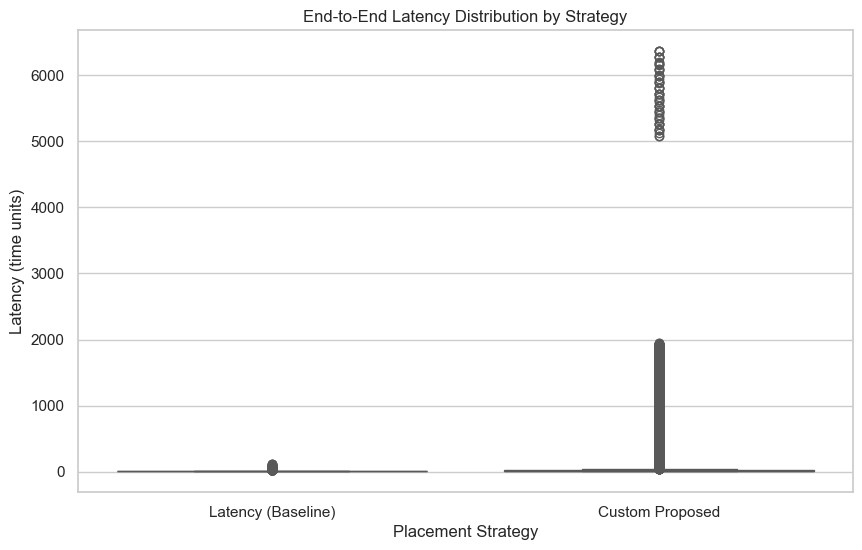

/var/folders/vh/g_6xn8xs7c39py3hmlk6m3nm0000gn/T/ipykernel_65398/173178218.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Strategy', y='latency', data=df_results, palette="Set2")


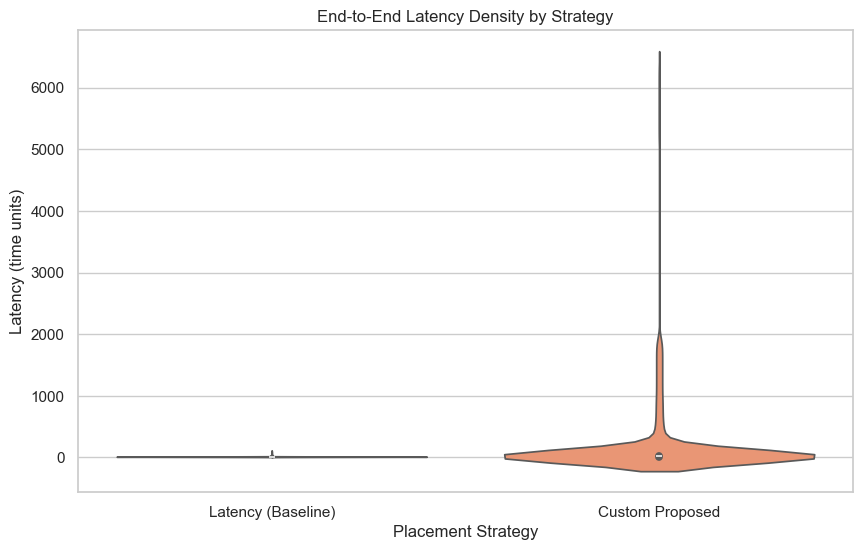

In [138]:
# Visualize Latency Distribution
plt.figure(figsize=(10, 6))
sns.boxplot(x='Strategy', y='latency', data=df_results, palette="Set2")
plt.title('End-to-End Latency Distribution by Strategy')
plt.ylabel('Latency (time units)')
plt.xlabel('Placement Strategy')
plt.show()

# Violin Plot for density
plt.figure(figsize=(10, 6))
sns.violinplot(x='Strategy', y='latency', data=df_results, palette="Set2")
plt.title('End-to-End Latency Density by Strategy')
plt.ylabel('Latency (time units)')
plt.xlabel('Placement Strategy')
plt.show()

             Strategy  Total Bytes Transferred
0     Custom Proposed                 39783895
1  Latency (Baseline)                 36225283


/var/folders/vh/g_6xn8xs7c39py3hmlk6m3nm0000gn/T/ipykernel_65398/2933405023.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Strategy', y='Total Bytes Transferred', data=network_usage, palette="viridis")


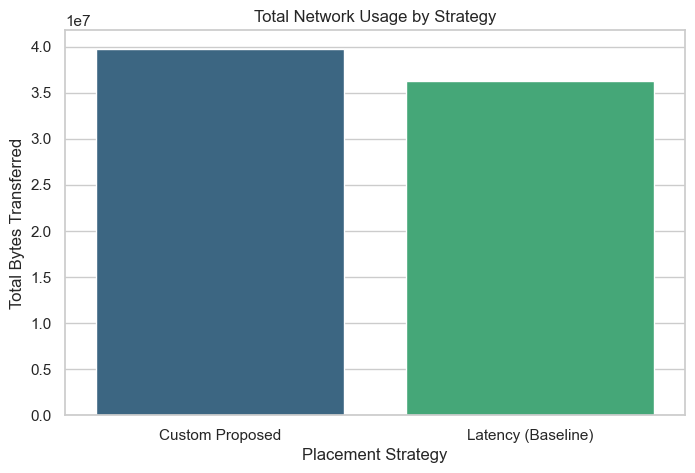

In [139]:
# Calculate Total Network Usage (Bytes Transferred)
network_usage = df_link_all.groupby('Strategy')['size'].sum().reset_index()
network_usage.columns = ['Strategy', 'Total Bytes Transferred']

print(network_usage)

# Visualize Network Usage
plt.figure(figsize=(8, 5))
sns.barplot(x='Strategy', y='Total Bytes Transferred', data=network_usage, palette="viridis")
plt.title('Total Network Usage by Strategy')
plt.ylabel('Total Bytes Transferred')
plt.xlabel('Placement Strategy')
plt.show()

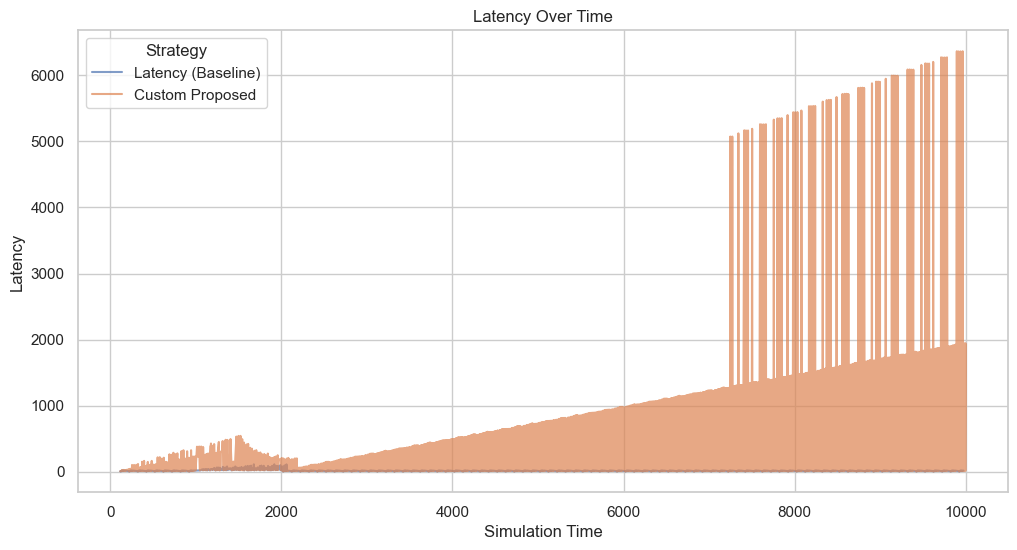

In [140]:
# Latency Over Time
plt.figure(figsize=(12, 6))
sns.lineplot(x='time_reception', y='latency', hue='Strategy', data=df_results, alpha=0.7)
plt.title('Latency Over Time')
plt.xlabel('Simulation Time')
plt.ylabel('Latency')
plt.show()

In [141]:
# Summary Statistics
summary_stats = df_results.groupby('Strategy')['latency'].agg(['mean', 'min', 'max', 'std', 'count']).reset_index()
summary_stats = summary_stats.merge(network_usage, on='Strategy')

print("Summary Statistics Table:")
display(summary_stats)

Summary Statistics Table:


,Strategy,mean,min,max,std,count,Total Bytes Transferred
0,Custom Proposed,188.462311,8.740411,6362.123465,662.872340,6243,39783895
1,Latency (Baseline),13.762177,8.740476,113.955574,6.124205,7286,36225283
